# Notebook 1 — Occupancy Raster Generation

**Stage 1 of 4** · part of the Scan-to-BIM room-segmentation pipeline.


> **Pipeline execution order: `1 -> 2 -> 3 -> 4`.**
> 1 occupancy · 2 watershed (room masks) · 3 boundary-ring wall assignment · 4 SAM
> refinement. Wall assignment begins "obtain room mask `M_i`", and room masks are produced
> only by the watershed, so the watershed is stage 2 and wall assignment stage 3. Each
> notebook also loads what it needs from the previous stage's ZIP, so a stage can be re-run
> on its own as long as the stages it depends on have been run once.


## Purpose
Convert the segmented point cloud (walls / windows / doors) into the 2-D rasters every
later stage builds on, plus the coordinate transform that ties pixels to world metres.

## Inputs
- **Point cloud** at `CFG.file_path` (e.g. `area1.xyz`), in the original
  format/units. This is an external input, not produced by another stage.

## Outputs  (`{out_root}/stage1_occupancy/`, zipped to `stage1_occupancy.zip`)
- `occupancy.png` — binary occupancy image (0 = wall, 255 = free).
- `wall_mask.npy` — bool occupancy wall pixels (the watershed's segmentation input).
- `wallness.npy` — bool vertical-extent wall raster (the **wall source** for Notebook 3).
- `coverage.npy` — bool scan-coverage raster (used by the watershed's void rejection).
- `transform.json` — grid transform + floor/ceiling heights + provenance.
- `config.json` — full configuration snapshot.

## Behaviour
Stages: load -> slab-crop -> rasterise path. `rasterize_wallness`
and `rasterize_coverage` are preserved unchanged.

## Assumptions
- The cloud is converted to metres on load (`units_per_meter`) and voxel-downsampled
  deterministically, so re-loading it downstream reproduces the same transform.

> **Two wall rasters, two different jobs — don't confuse them.**
> This stage emits *both* `wall_mask` and `wallness`, and each feeds a different later stage:
>
> | Raster | Built from | Consumed by | On by default? |
> |---|---|---|---|
> | `wall_mask` (binary occupancy) | the slab crop | **watershed segmentation input** (NB2) | yes |
> | `wallness` (vertical-extent, furniture-suppressed) | the **full** cloud | **wall source for boundary-ring wall assignment** (NB3) | **yes — always** |
>
> Neither output is dead weight: `wallness` is loaded by NB3 and used on *every* run, regardless of any flag.
>
> The one knob here is **`CFG.use_wallness` (default `False`)**. It does **not** turn `wallness`
> on or off — it only decides whether the **watershed** (NB2) segments on `wallness` instead of
> `wall_mask`. Out of the box: **watershed → `wall_mask`, wall assignment → `wallness`**. Set
> `use_wallness: true` in `params.yaml` only if you want the watershed itself to segment on the
> vertical-extent raster (see `wallness_min_span_frac`, default `0.5`).

### Setup
**Run-All ready.** Edit **`params.yaml`** (the only config surface), then run every cell top
to bottom — no cell edits, ever. `load_config()` reads it over the `Config` defaults.

> **Skipped `pip install -e .`?** Prepend this 2-line path-shim to the cell below so
> `import scan2bim` resolves from `notebooks/preprocessing/`:
> `import sys, os; sys.path.insert(0, os.path.abspath('../..'))`

In [ ]:
# ============================== scan2bim setup (local) ==============================
# One loader replaces the old ~30-line bootstrap and the per-notebook config cell. With
# `pip install -e .`, `import scan2bim` works from anywhere; `load_config()` reads
# params.yaml (the ONLY file you edit) over the Config defaults and resolves paths.
import os
import numpy as np
import scan2bim
from scan2bim import artifacts as A, viz

CFG = scan2bim.load_config()        # params.yaml over Config defaults; file_path/out_root -> abs
SHOW_DEBUG = True                   # set False to skip the QA plots
print('scan2bim', scan2bim.__version__, 'loaded from', os.path.dirname(scan2bim.__file__))
print('input cloud :', CFG.file_path, '| exists:', os.path.isfile(CFG.file_path))
print('output root :', CFG.out_root)

scan2bim 1.0.0 loaded from C:\onestruction\scan2bim
input cloud : C:\onestruction\data\area3.xyz | exists: True
output root : C:\onestruction\scan2bim_out


### Step 1 — Load the point cloud (reuses the original Drive loader)

In [ ]:
pcd, pts = scan2bim.load_point_cloud(CFG)
floor_z, ceil_z = scan2bim.estimate_ceiling(pts[:, CFG.up_axis], return_floor=True)
print(f'floor_z={floor_z:.3f}  ceil_z={ceil_z:.3f}  (m)')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


units/meter = 1.0  (raw max extent 30.33)
points before clean: 2,190,836
points after voxel (0.02 m): 2,135,191
floor_z=-0.024  ceil_z=3.026  (m)


### Step 2 — Extract the horizontal wall-height slab

In [ ]:
slab_pts, slab_mask, slab_info = scan2bim.crop_vertical(pts, CFG, debug=True, return_info=True)

[crop_vertical] mode=ceiling  band(m,mean)=[2.19,2.59]  kept 215,548/2,135,191 (10.1%)  local ceiling range [-0.06,3.05] m


### Step 3 — Rasterise occupancy, wallness and coverage
`occupancy` comes from the slab; `wallness` and `coverage` are computed from the **full**
cloud (preserved exactly from the original), all aligned to the same transform.

In [ ]:
occ, tf = scan2bim.rasterize_topdown(
    slab_pts, CFG.pixel_m, up_axis=CFG.up_axis,
    min_points_per_cell=CFG.min_points_per_cell, thicken=CFG.thicken_px)
wall_mask = (occ == 0)
wallness = scan2bim.rasterize_wallness(pts, CFG, tf)
coverage = scan2bim.rasterize_coverage(pts, CFG, tf)
print('raster size (H x W):', occ.shape,
      '| wall px:', int(wall_mask.sum()),
      '| wallness px:', int(wallness.sum()),
      '| covered px:', int(coverage.sum()))

raster size (H x W): (856, 1011) | wall px: 58718 | wallness px: 210516 | covered px: 407105


### Optional — QA plots

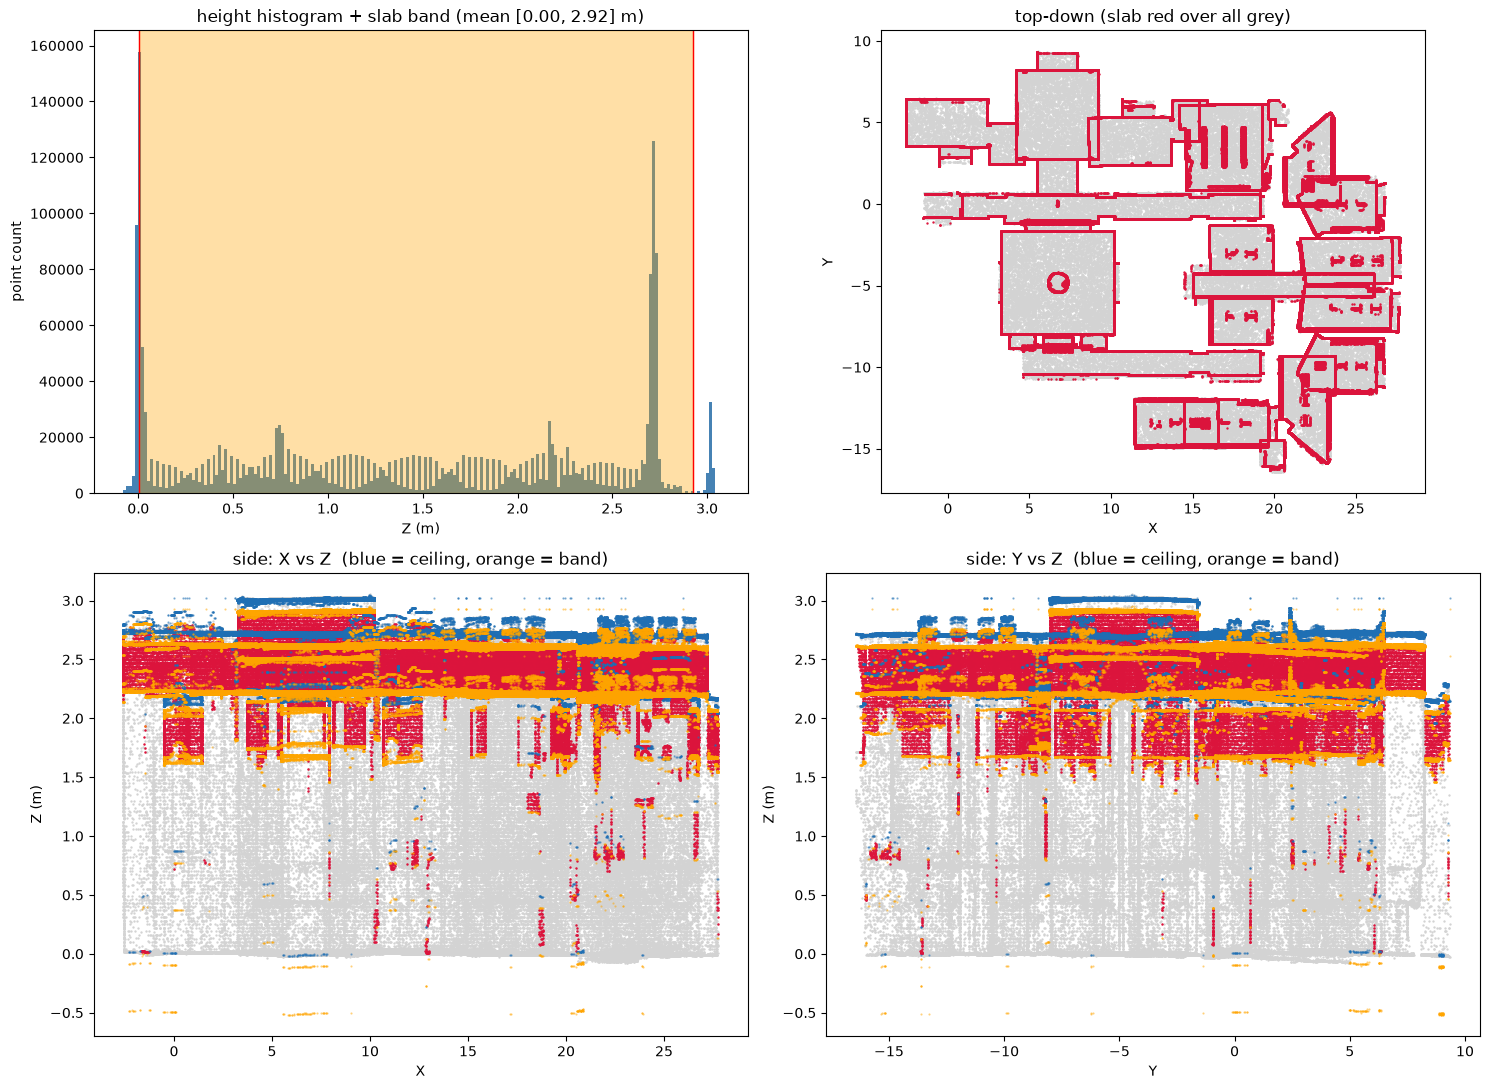

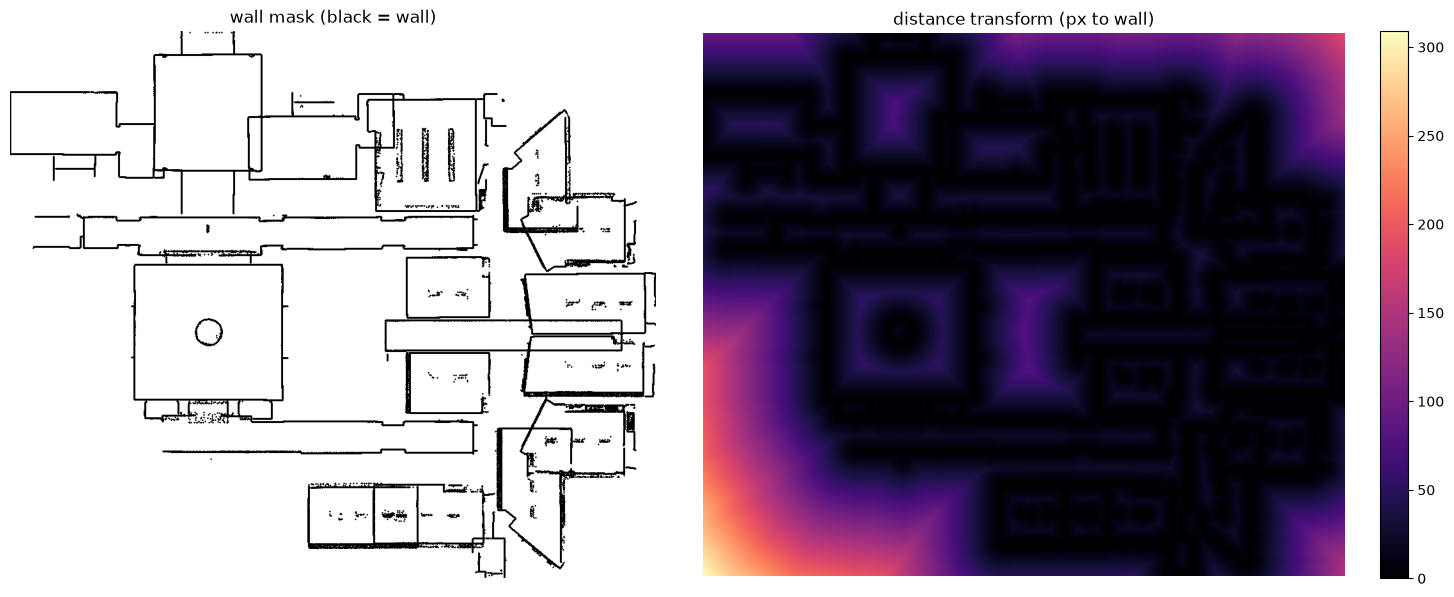

In [ ]:
if SHOW_DEBUG:
    viz.show_slab_debug(pts, slab_mask, CFG.up_axis, info=slab_info)
    viz.show_raster_debug(wall_mask)

### Step 4 — Save outputs and package the ZIP

In [ ]:
out_dir = A.ensure_dir(A.stage_dir(CFG.out_root, A.STAGE1))
A.save_png(os.path.join(out_dir, A.OCC_PNG), occ)
A.save_npy(os.path.join(out_dir, A.WALLMASK_NPY), wall_mask)
A.save_npy(os.path.join(out_dir, A.WALLNESS_NPY), wallness)
A.save_npy(os.path.join(out_dir, A.COVERAGE_NPY), coverage)
A.save_transform(os.path.join(out_dir, A.TRANSFORM_JSON), tf, extra=dict(
    floor_z=float(floor_z), ceil_z=float(ceil_z),
    units_per_meter=CFG.units_per_meter, up_axis=CFG.up_axis,
    file_path=CFG.file_path, voxel_m=CFG.voxel_m))
A.save_config(os.path.join(out_dir, A.CONFIG_JSON), CFG)
zip_path = A.package_stage(CFG.out_root, A.STAGE1)
print('packaged ->', zip_path)

packaged -> C:\onestruction\scan2bim_out\stage1_occupancy.zip
